In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip" -d /content/data

unzip:  cannot find or open /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip, /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip.zip or /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip.ZIP.


In [3]:
!ls /content/drive/MyDrive/

'Colab Notebooks'   skin-disease-dermnet.zip


In [4]:
!unzip "/content/drive/MyDrive/skin-disease-dermnet.zip" -d /content/data

Archive:  /content/drive/MyDrive/skin-disease-dermnet.zip
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (193).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (194).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (195).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (196).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (197).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (198).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (199).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (200).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (201).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (202).jpg  
  

In [5]:
## Check Folder Structure
import os

print(os.listdir('/content/data'))
print(os.listdir('/content/data/Penyakit Kulit'))

['Penyakit Kulit']
['test', 'train']


In [6]:
## Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
## Define Image Settings
img_size = (224, 224)
batch_size = 32

In [8]:
## Create Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

In [9]:
##Load Training Data
train_data = train_datagen.flow_from_directory(
    '/content/data/Penyakit Kulit/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4416 images belonging to 23 classes.


In [10]:
## Load Testing Data
test_data = test_datagen.flow_from_directory(
    '/content/data/Penyakit Kulit/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 460 images belonging to 23 classes.


In [11]:
print("Classes:", train_data.class_indices)
print("Number of training images:", train_data.samples)
print("Number of testing images:", test_data.samples)

Classes: {'Acne and Rosacea': 0, 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions': 1, 'Atopic Dermatitis': 2, 'Bullous Disease': 3, 'Cellulitis Impetigo and other Bacterial Infections': 4, 'Eczema': 5, 'Exanthems and Drug Eruptions': 6, 'Hair Loss Photos Alopecia and other Hair Diseases': 7, 'Herpes HPV and other STDs': 8, 'Light Diseases and Disorders of Pigmentation': 9, 'Lupus and other Connective Tissue Diseases': 10, 'Melanoma Skin Cancer Nevi and Moles': 11, 'Nail Fungus and other Nail Disease': 12, 'Poison Ivy Photos and other Contact Dermatitis': 13, 'Psoriasis pictures Lichen Planus and Related Diseases': 14, 'Scabies Lyme Disease and other Infestations and Bites': 15, 'Seborrheic Keratoses and other Benign Tumors': 16, 'Systemic Disease': 17, 'Tinea Ringworm Candidiasis and other Fungal Infections': 18, 'Urticaria Hives': 19, 'Vascular Tumors': 20, 'Vasculitis Photos': 21, 'Warts Molluscum and other Viral Infections': 22}
Number of training images: 4416
Nu

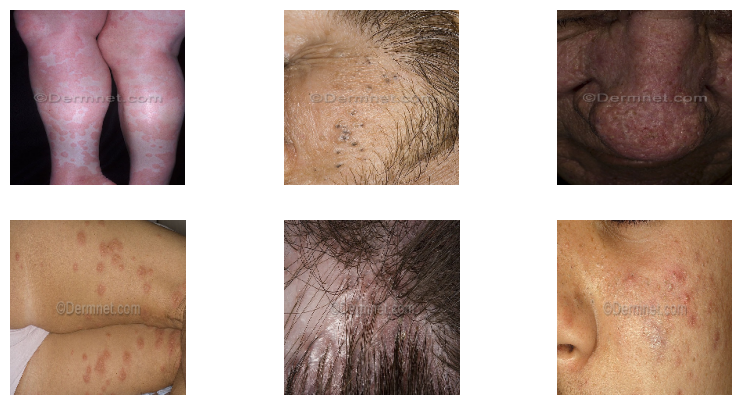

In [12]:
## Display Sample Images
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()